# Лабораторная работа №2: Кластеризация данных

## Цель работы
Освоить практическое применение методов кластеризации данных, в частности алгоритмов K-средних и DBSCAN, на различных наборах данных.

## Описание методов
**Кластеризация** – это метод машинного обучения без учителя, направленный на разделение набора объектов на группы (кластеры) таким образом, чтобы объекты внутри одной группы были более похожи друг на друга, чем на объекты из других групп.

**Метод K-средних** – это итеративный алгоритм, который разбивает набор данных на K предопределенных непересекающихся подгрупп (кластеров), где каждая точка данных принадлежит только одному кластеру.

**Метод DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) – это алгоритм кластеризации, основанный на плотности. Он группирует вместе точки, которые находятся близко друг к другу в областях высокой плотности, отмечая точки в областях с низкой плотностью как выбросы.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("Библиотеки загружены успешно")


Библиотеки загружены успешно


## Часть 1: Генерация данных и применение методов кластеризации


### 1.1. Генерация синтетических данных


Размер сгенерированной выборки: (500, 2)
Количество кластеров: 5
Количество образцов: 500


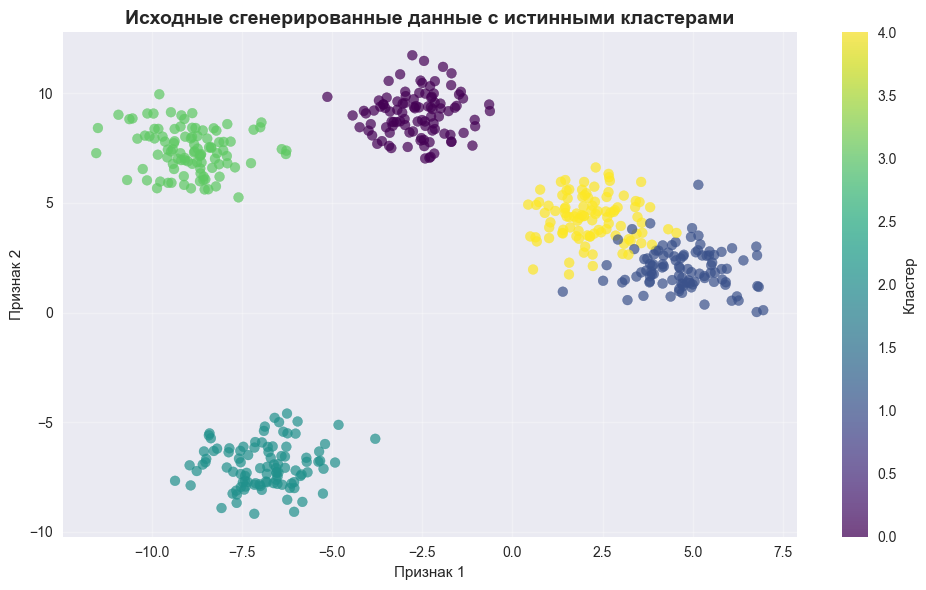

In [2]:
# Генерация данных с помощью make_blobs
# Создаем выборку с 5 кластерами
n_samples = 500
n_features = 2
centers = 5
random_state = 42

X_synthetic, y_synthetic = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=centers,
    cluster_std=1.0,
    random_state=random_state
)

print(f"Размер сгенерированной выборки: {X_synthetic.shape}")
print(f"Количество кластеров: {centers}")
print(f"Количество образцов: {n_samples}")

# Визуализация исходных данных
plt.figure(figsize=(10, 6))
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_synthetic, cmap='viridis', s=50, alpha=0.7)
plt.title('Исходные сгенерированные данные с истинными кластерами', fontsize=14, fontweight='bold')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Кластер')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('synthetic_original.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.2. Применение метода K-средних


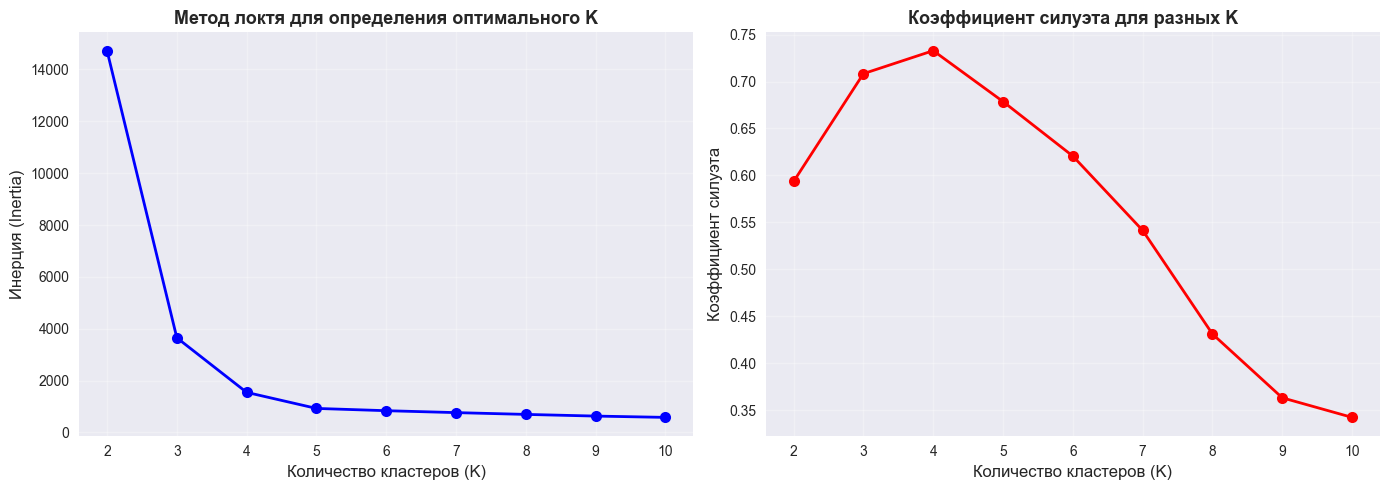

Оптимальное K по методу локтя: 5
Оптимальное K по коэффициенту силуэта: 4
Максимальный коэффициент силуэта: 0.7328


In [3]:
# Метод локтя для определения оптимального числа кластеров
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_synthetic)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_synthetic, kmeans.labels_))

# Визуализация метода локтя
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График метода локтя
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Количество кластеров (K)', fontsize=12)
ax1.set_ylabel('Инерция (Inertia)', fontsize=12)
ax1.set_title('Метод локтя для определения оптимального K', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(K_range)

# График коэффициента силуэта
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Количество кластеров (K)', fontsize=12)
ax2.set_ylabel('Коэффициент силуэта', fontsize=12)
ax2.set_title('Коэффициент силуэта для разных K', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(K_range)

plt.tight_layout()
plt.savefig('synthetic_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# Определение оптимального K
optimal_k_elbow = 5  # Видно из графика локтя
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]

print(f"Оптимальное K по методу локтя: {optimal_k_elbow}")
print(f"Оптимальное K по коэффициенту силуэта: {optimal_k_silhouette}")
print(f"Максимальный коэффициент силуэта: {max(silhouette_scores):.4f}")


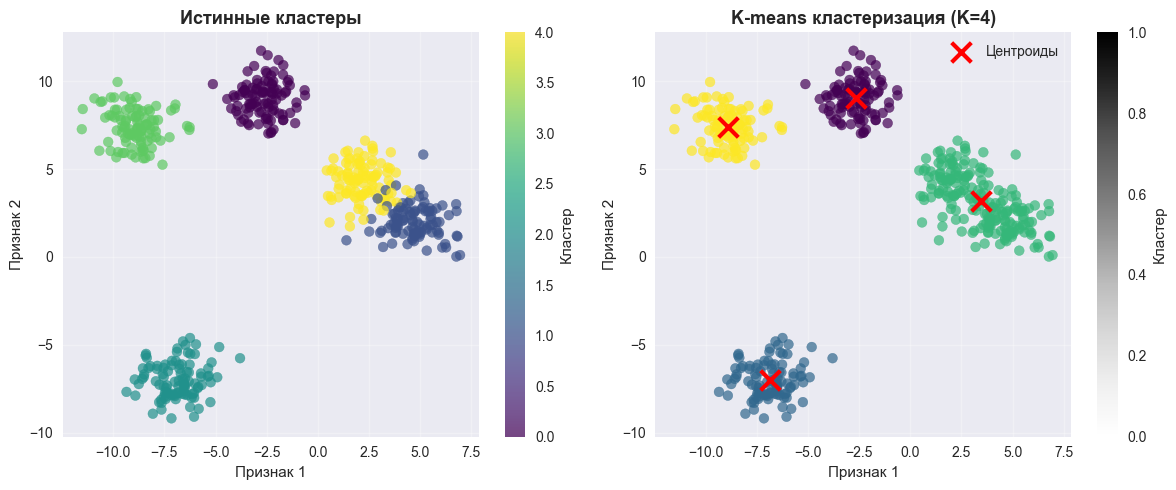

Средний коэффициент силуэта для K-means: 0.7328


In [4]:
# Применение K-means с оптимальным количеством кластеров
kmeans_optimal = KMeans(n_clusters=optimal_k_silhouette, random_state=42, n_init=10)
y_kmeans = kmeans_optimal.fit_predict(X_synthetic)

# Визуализация результатов K-means
plt.figure(figsize=(12, 5))

# Сравнение с истинными кластерами
plt.subplot(1, 2, 1)
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_synthetic, cmap='viridis', s=50, alpha=0.7)
plt.title('Истинные кластеры', fontsize=13, fontweight='bold')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Кластер')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.7)
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1], 
            c='red', marker='x', s=200, linewidths=3, label='Центроиды')
plt.title(f'K-means кластеризация (K={optimal_k_silhouette})', fontsize=13, fontweight='bold')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Кластер')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('synthetic_kmeans_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Оценка качества
silhouette_avg = silhouette_score(X_synthetic, y_kmeans)
print(f"Средний коэффициент силуэта для K-means: {silhouette_avg:.4f}")


e 

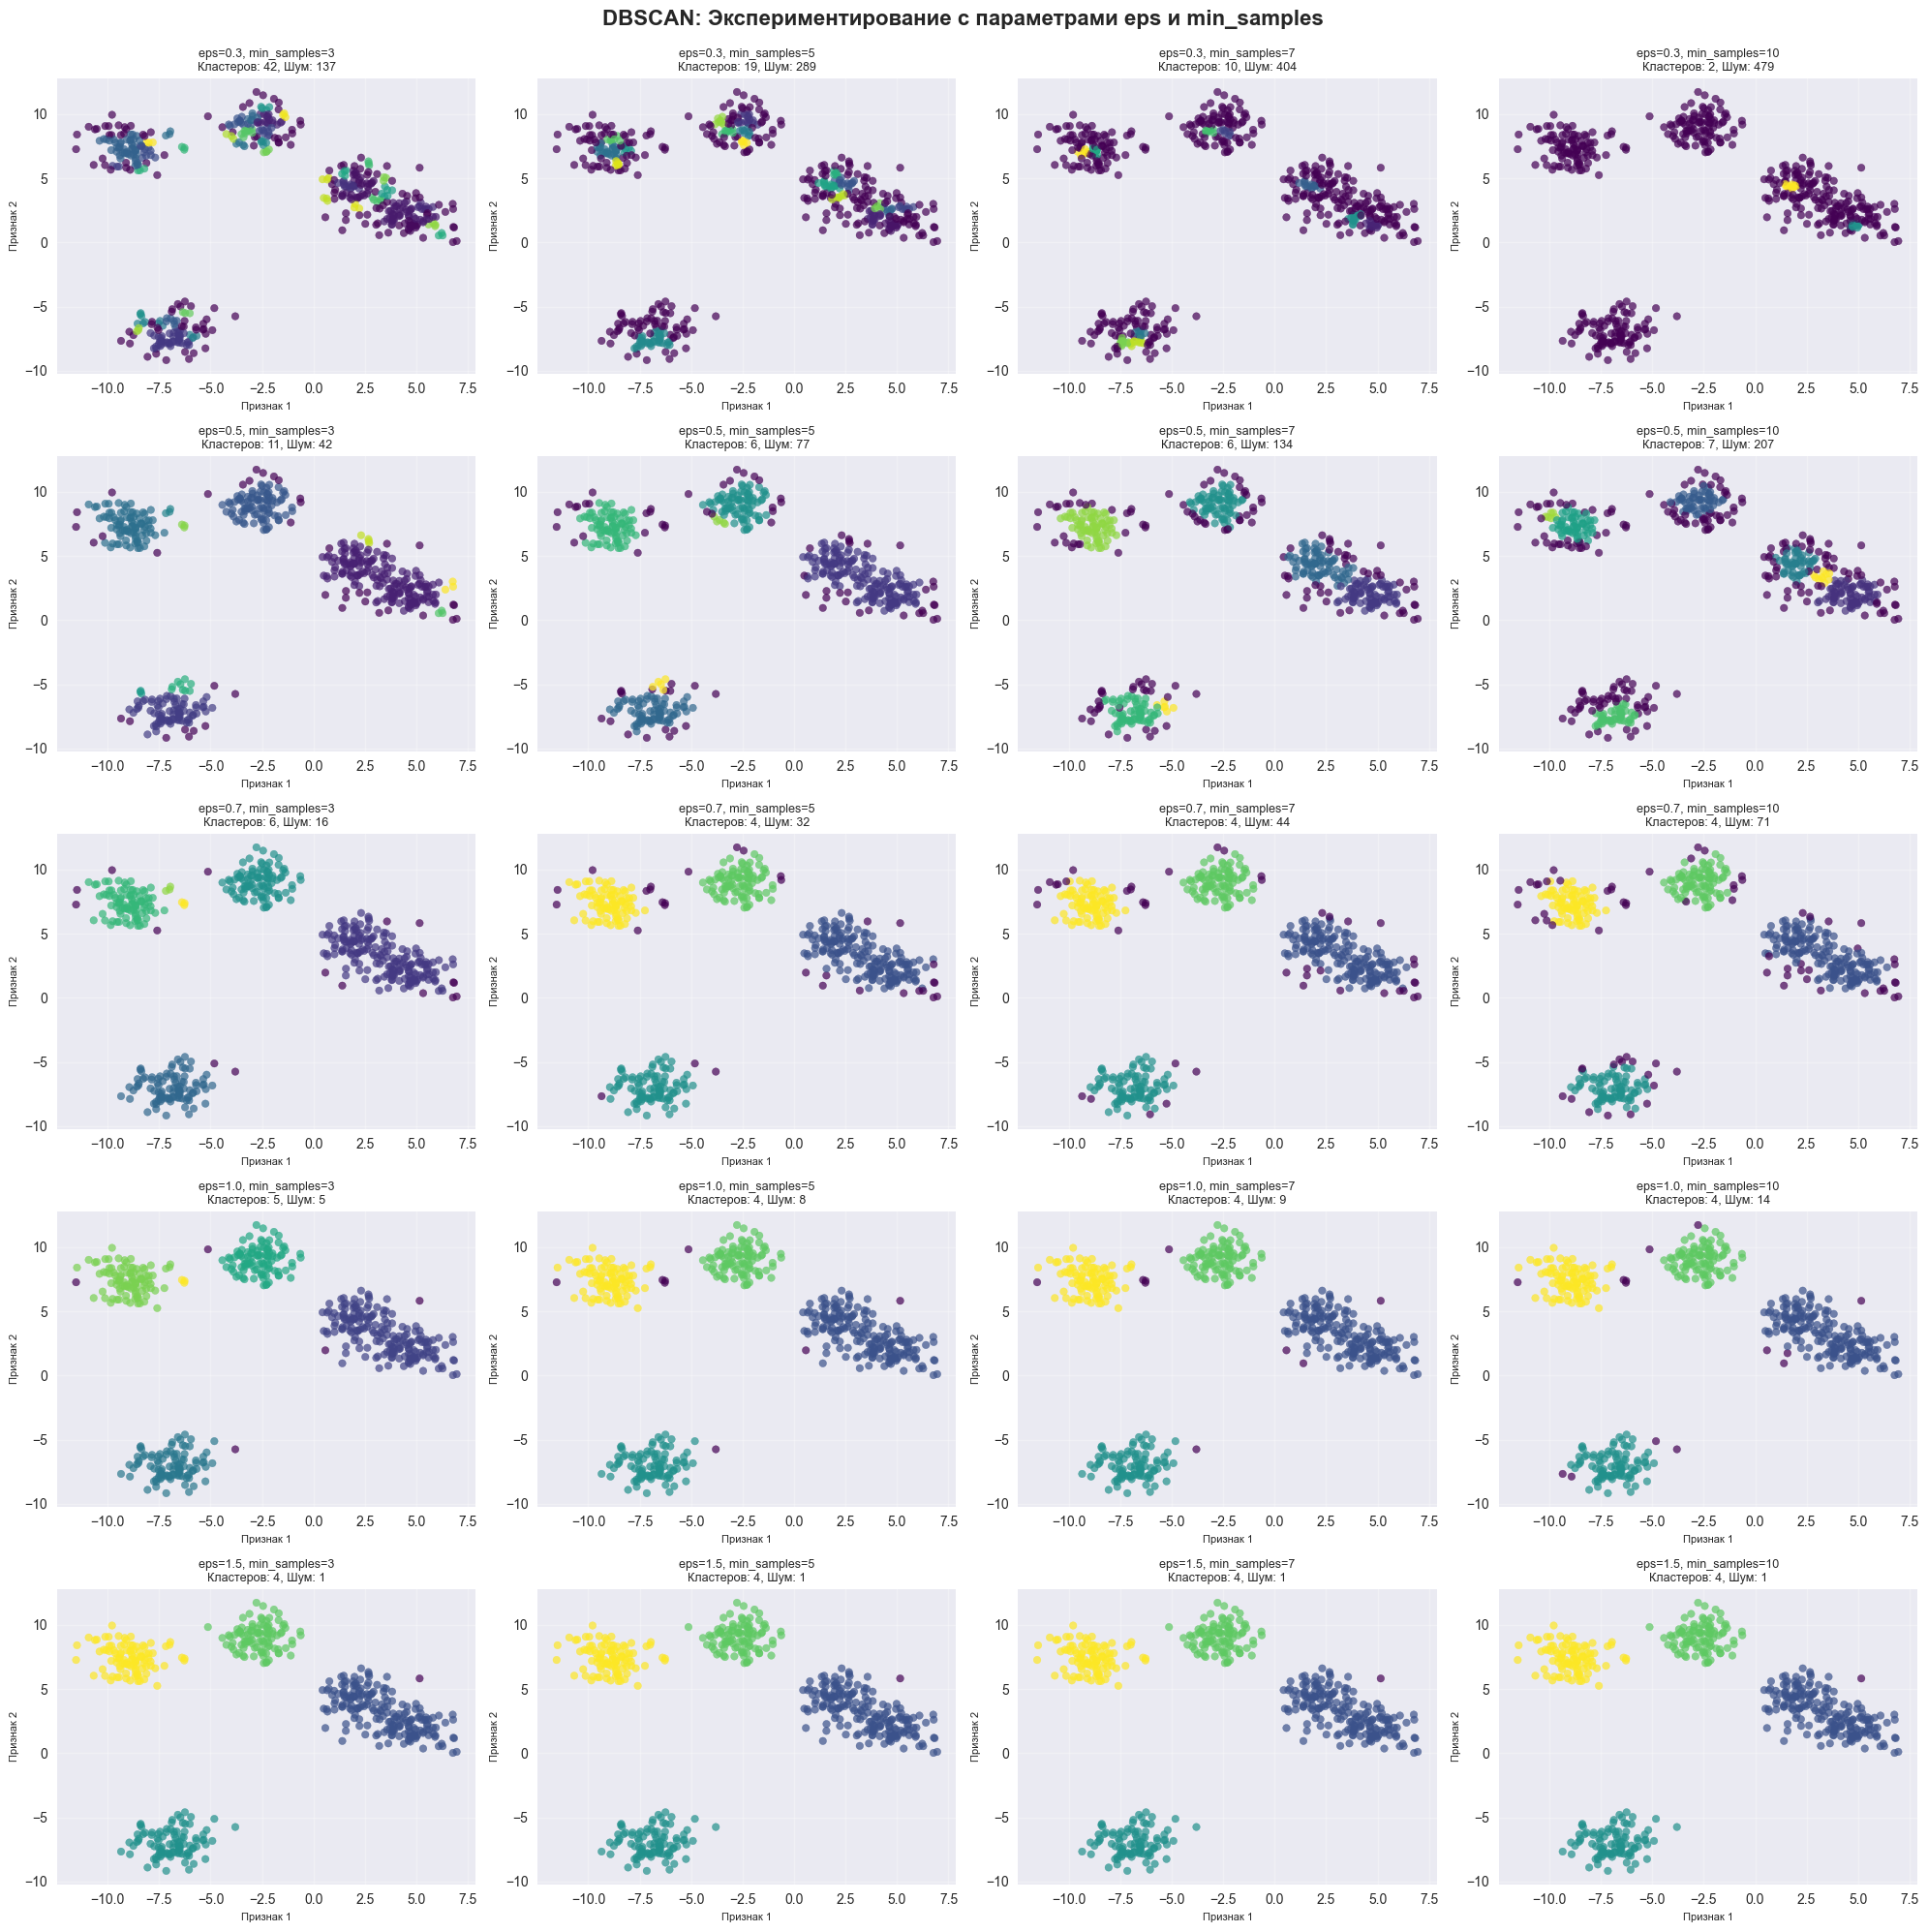

In [5]:
# Экспериментирование с параметрами DBSCAN
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 7, 10]

fig, axes = plt.subplots(len(eps_values), len(min_samples_values), 
                         figsize=(20, 20))
fig.suptitle('DBSCAN: Экспериментирование с параметрами eps и min_samples', 
             fontsize=16, fontweight='bold', y=0.995)

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_synthetic)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        ax = axes[i, j]
        scatter = ax.scatter(X_synthetic[:, 0], X_synthetic[:, 1], 
                            c=labels, cmap='viridis', s=30, alpha=0.7)
        ax.set_title(f'eps={eps}, min_samples={min_samples}\n'
                    f'Кластеров: {n_clusters}, Шум: {n_noise}', 
                    fontsize=9)
        ax.set_xlabel('Признак 1', fontsize=8)
        ax.set_ylabel('Признак 2', fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('synthetic_dbscan_parameters.png', dpi=150, bbox_inches='tight')
plt.show()


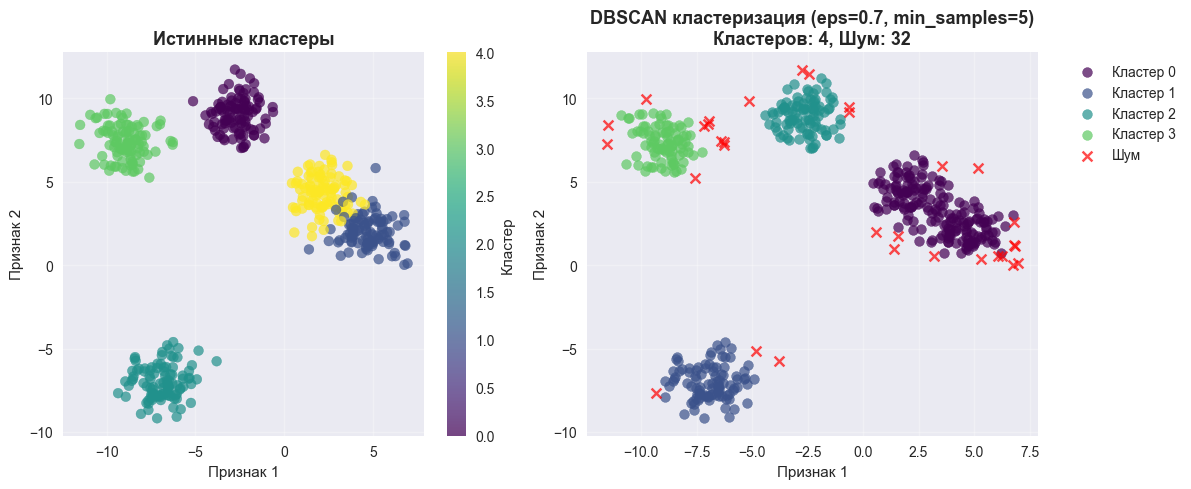

Количество кластеров DBSCAN: 4
Количество точек-шума: 32
Коэффициент силуэта для DBSCAN (без шума): 0.7525


In [6]:
# Выбор оптимальных параметров DBSCAN
# Для синтетических данных с четкими кластерами
optimal_eps = 0.7
optimal_min_samples = 5

dbscan_optimal = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
y_dbscan = dbscan_optimal.fit_predict(X_synthetic)

n_clusters_dbscan = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)

# Визуализация результатов DBSCAN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_synthetic, cmap='viridis', s=50, alpha=0.7)
plt.title('Истинные кластеры', fontsize=13, fontweight='bold')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Кластер')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
unique_labels = set(y_dbscan)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'red'
        marker = 'x'
        label = 'Шум'
    else:
        marker = 'o'
        label = f'Кластер {k}'
    class_member_mask = (y_dbscan == k)
    xy = X_synthetic[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=50, alpha=0.7, label=label)

plt.title(f'DBSCAN кластеризация (eps={optimal_eps}, min_samples={optimal_min_samples})\n'
          f'Кластеров: {n_clusters_dbscan}, Шум: {n_noise}', 
          fontsize=13, fontweight='bold')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('synthetic_dbscan_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Количество кластеров DBSCAN: {n_clusters_dbscan}")
print(f"Количество точек-шума: {n_noise}")
if n_noise < len(X_synthetic) * 0.1:  # Если шума меньше 10%
    silhouette_dbscan = silhouette_score(X_synthetic[y_dbscan != -1], 
                                         y_dbscan[y_dbscan != -1])
    print(f"Коэффициент силуэта для DBSCAN (без шума): {silhouette_dbscan:.4f}")


## Часть 2: Кластеризация датасета Penguins


### 2.1. Загрузка и предварительный анализ данных


In [7]:
# Загрузка датасета
df_penguins = pd.read_csv('penguins.csv')
print(f"Размер датасета: {df_penguins.shape}")
print(f"\nКолонки: {df_penguins.columns.tolist()}")
print(f"\nПервые строки:")
df_penguins.head()


Размер датасета: (344, 5)

Колонки: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Первые строки:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [8]:
# Проверка данных
print("Информация о датасете:")
print(df_penguins.info())
print("\nПропущенные значения:")
print(df_penguins.isnull().sum())
print("\nОписательная статистика:")
print(df_penguins.describe())


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB
None

Пропущенные значения:
culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

Описательная статистика:
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
count        342.000000       342.000000         342.000000   342.000000
mean          43.921930        17.151170         214.014620  4201.754386
std            5.459584         1.974793         260.558057   801.954536
min       

In [9]:
# Обработка данных
# Удаление строк с пропущенными значениями
df_penguins_clean = df_penguins.dropna()

# Проверка на выбросы (например, отрицательные значения или нереалистичные)
print("Проверка на выбросы:")
print(f"Отрицательные значения flipper_length_mm: {(df_penguins_clean['flipper_length_mm'] < 0).sum()}")
print(f"Значения flipper_length_mm > 300: {(df_penguins_clean['flipper_length_mm'] > 300).sum()}")
print(f"Значения body_mass_g > 10000: {(df_penguins_clean['body_mass_g'] > 10000).sum()}")

# Удаление выбросов
df_penguins_clean = df_penguins_clean[
    (df_penguins_clean['flipper_length_mm'] > 0) & 
    (df_penguins_clean['flipper_length_mm'] < 300) &
    (df_penguins_clean['body_mass_g'] < 10000)
]

print(f"\nРазмер датасета после очистки: {df_penguins_clean.shape}")

# Выбор числовых признаков для кластеризации
numeric_features = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_penguins = df_penguins_clean[numeric_features].values

print(f"\nПризнаки для кластеризации: {numeric_features}")
print(f"Размер матрицы признаков: {X_penguins.shape}")

# Стандартизация данных
scaler = StandardScaler()
X_penguins_scaled = scaler.fit_transform(X_penguins)

print("\nДанные стандартизированы")


Проверка на выбросы:
Отрицательные значения flipper_length_mm: 1
Значения flipper_length_mm > 300: 1
Значения body_mass_g > 10000: 0

Размер датасета после очистки: (333, 5)

Признаки для кластеризации: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
Размер матрицы признаков: (333, 4)

Данные стандартизированы


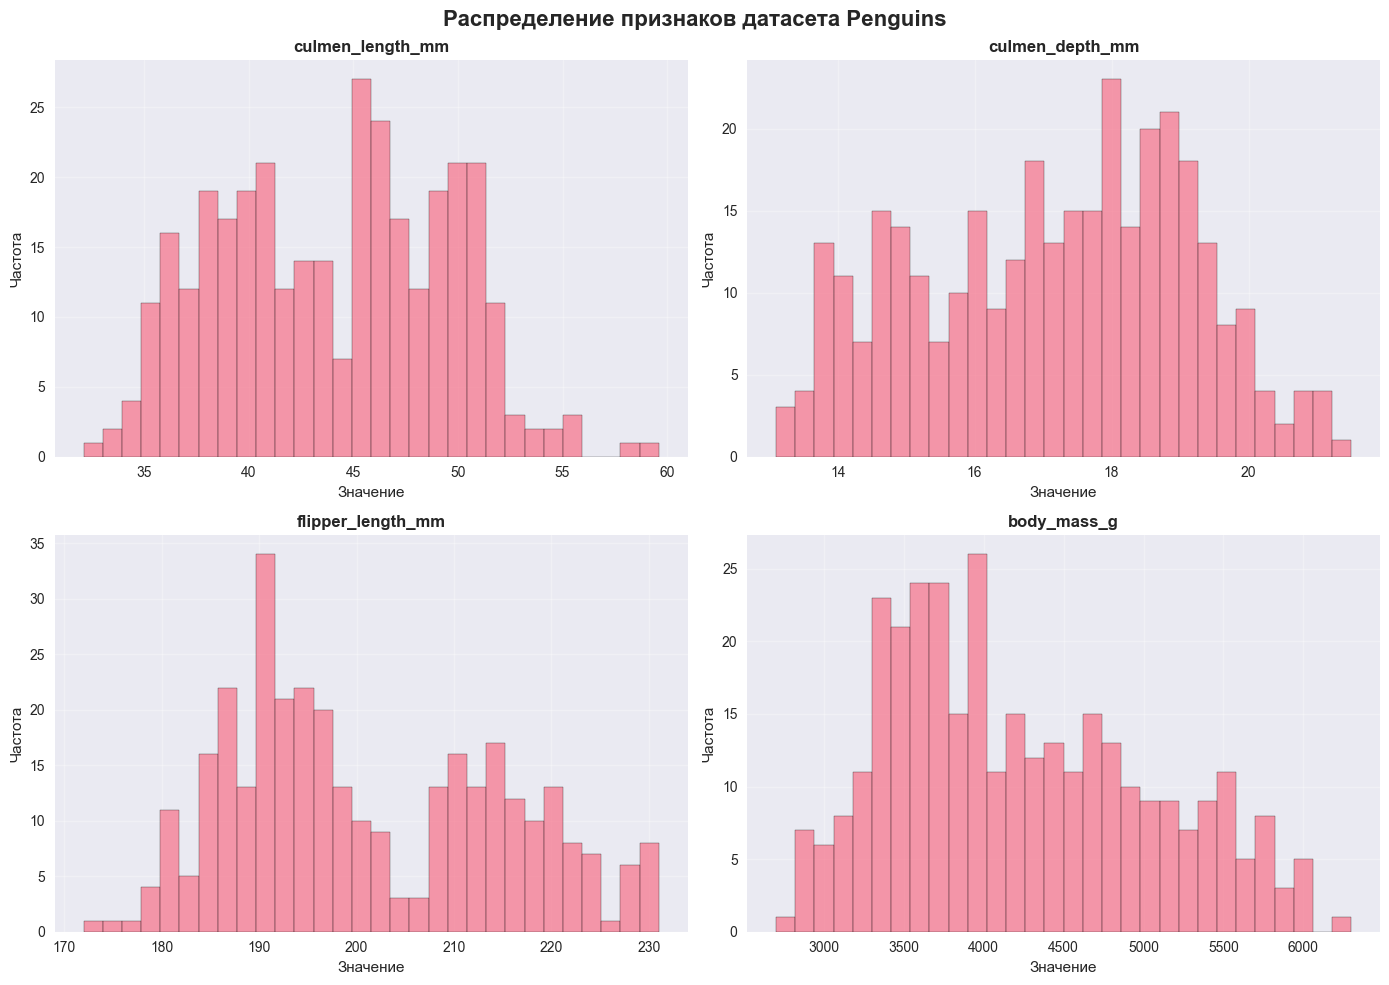

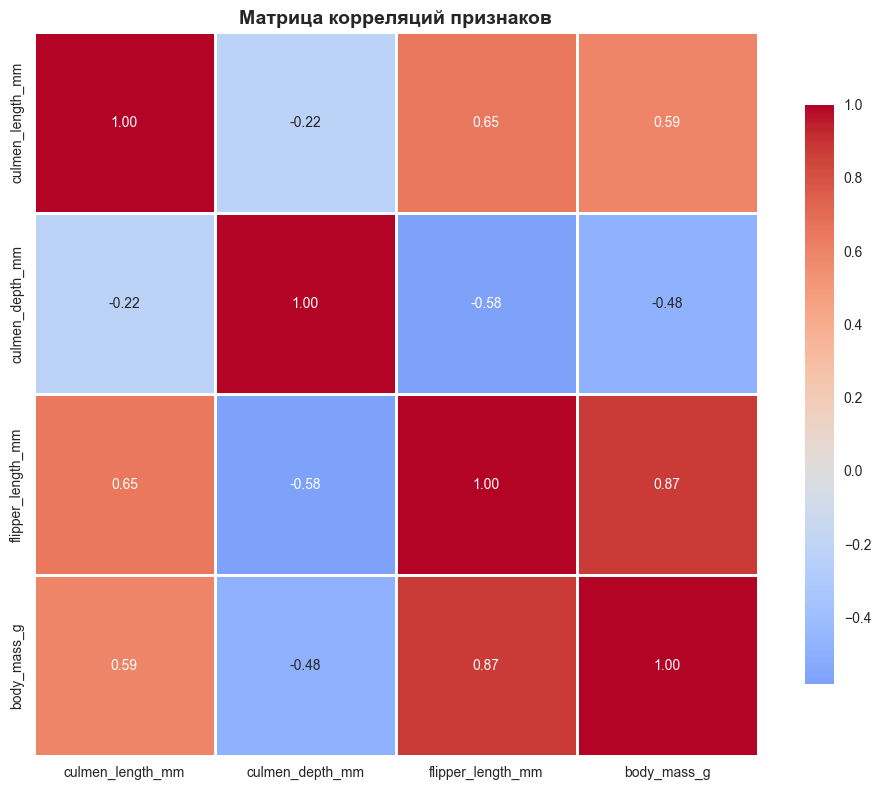

In [10]:
# Визуализация распределения признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределение признаков датасета Penguins', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df_penguins_clean[feature], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('penguins_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Матрица корреляций
plt.figure(figsize=(10, 8))
correlation_matrix = df_penguins_clean[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('penguins_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.2. Применение метода K-средних к датасету Penguins


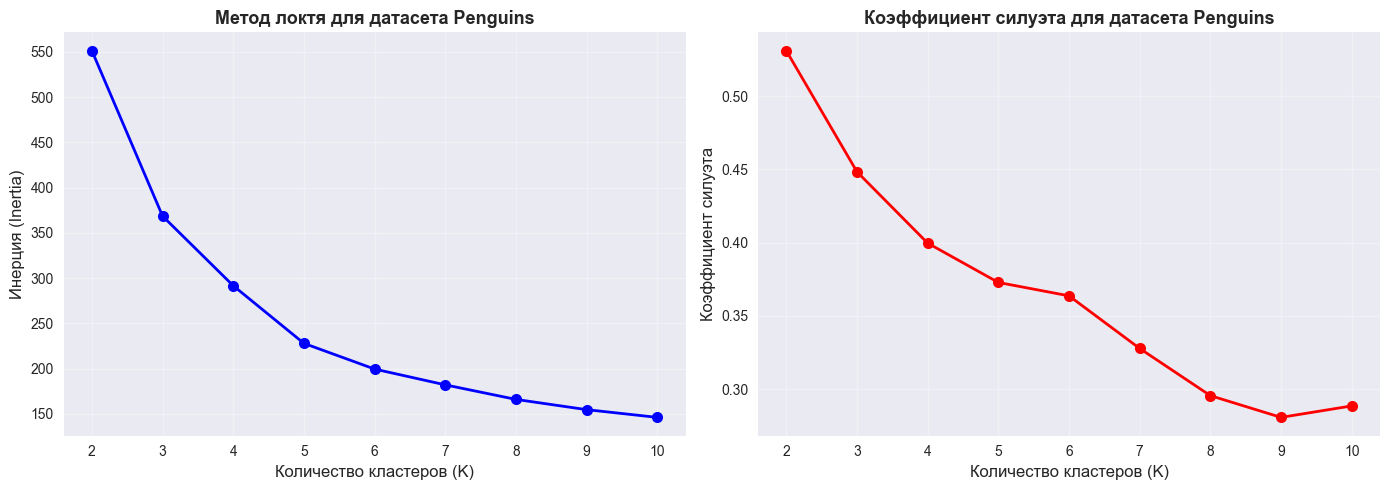

Оптимальное K по коэффициенту силуэта: 2
Максимальный коэффициент силуэта: 0.5311


In [11]:
# Метод локтя и коэффициент силуэта для датасета Penguins
inertias_penguins = []
silhouette_scores_penguins = []
K_range_penguins = range(2, 11)

for k in K_range_penguins:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_penguins_scaled)
    inertias_penguins.append(kmeans.inertia_)
    silhouette_scores_penguins.append(silhouette_score(X_penguins_scaled, kmeans.labels_))

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range_penguins, inertias_penguins, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Количество кластеров (K)', fontsize=12)
ax1.set_ylabel('Инерция (Inertia)', fontsize=12)
ax1.set_title('Метод локтя для датасета Penguins', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(K_range_penguins)

ax2.plot(K_range_penguins, silhouette_scores_penguins, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Количество кластеров (K)', fontsize=12)
ax2.set_ylabel('Коэффициент силуэта', fontsize=12)
ax2.set_title('Коэффициент силуэта для датасета Penguins', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(K_range_penguins)

plt.tight_layout()
plt.savefig('penguins_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_k_penguins = K_range_penguins[np.argmax(silhouette_scores_penguins)]
print(f"Оптимальное K по коэффициенту силуэта: {optimal_k_penguins}")
print(f"Максимальный коэффициент силуэта: {max(silhouette_scores_penguins):.4f}")


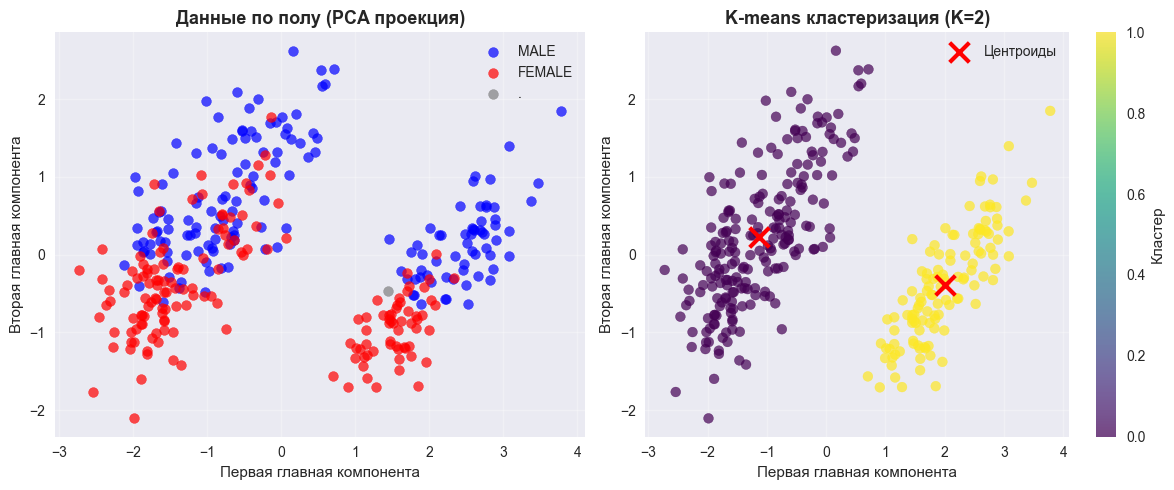

Средний коэффициент силуэта для K-means: 0.5311

Характеристики кластеров:

Кластер 0 (213 пингвинов):
culmen_length_mm       42.039437
culmen_depth_mm        18.357746
flipper_length_mm     191.892019
body_mass_g          3711.502347
dtype: float64

Кластер 1 (120 пингвинов):
culmen_length_mm       47.542500
culmen_depth_mm        15.002500
flipper_length_mm     217.233333
body_mass_g          5090.625000
dtype: float64


In [12]:
# Применение K-means с оптимальным K
kmeans_penguins = KMeans(n_clusters=optimal_k_penguins, random_state=42, n_init=10)
y_kmeans_penguins = kmeans_penguins.fit_predict(X_penguins_scaled)

# Визуализация результатов (используем PCA для снижения размерности до 2D)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_penguins_pca = pca.fit_transform(X_penguins_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Используем пол для визуализации истинной структуры
if 'sex' in df_penguins_clean.columns:
    sex_colors = {'MALE': 'blue', 'FEMALE': 'red'}
    for sex in df_penguins_clean['sex'].unique():
        if pd.notna(sex):
            mask = df_penguins_clean['sex'] == sex
            plt.scatter(X_penguins_pca[mask, 0], X_penguins_pca[mask, 1], 
                       c=sex_colors.get(sex, 'gray'), label=sex, s=50, alpha=0.7)
    plt.legend()
    plt.title('Данные по полу (PCA проекция)', fontsize=13, fontweight='bold')
else:
    plt.scatter(X_penguins_pca[:, 0], X_penguins_pca[:, 1], s=50, alpha=0.7)
    plt.title('Данные (PCA проекция)', fontsize=13, fontweight='bold')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter = plt.scatter(X_penguins_pca[:, 0], X_penguins_pca[:, 1], 
                     c=y_kmeans_penguins, cmap='viridis', s=50, alpha=0.7)
plt.scatter(pca.transform(kmeans_penguins.cluster_centers_)[:, 0],
            pca.transform(kmeans_penguins.cluster_centers_)[:, 1],
            c='red', marker='x', s=200, linewidths=3, label='Центроиды')
plt.title(f'K-means кластеризация (K={optimal_k_penguins})', fontsize=13, fontweight='bold')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(scatter, label='Кластер')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('penguins_kmeans_results.png', dpi=150, bbox_inches='tight')
plt.show()

silhouette_avg_penguins = silhouette_score(X_penguins_scaled, y_kmeans_penguins)
print(f"Средний коэффициент силуэта для K-means: {silhouette_avg_penguins:.4f}")

# Анализ кластеров
print("\nХарактеристики кластеров:")
for i in range(optimal_k_penguins):
    cluster_mask = y_kmeans_penguins == i
    cluster_data = df_penguins_clean[cluster_mask]
    print(f"\nКластер {i} ({cluster_mask.sum()} пингвинов):")
    print(cluster_data[numeric_features].mean())


### 2.3. Применение метода DBSCAN к датасету Penguins


In [13]:
# Экспериментирование с параметрами DBSCAN для датасета Penguins
eps_values_penguins = [0.3, 0.5, 0.7, 1.0]
min_samples_values_penguins = [3, 5, 7, 10]

results_dbscan = []

for eps in eps_values_penguins:
    for min_samples in min_samples_values_penguins:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_penguins_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 0 and n_noise < len(X_penguins_scaled) * 0.5:  # Игнорируем случаи с слишком большим шумом
            silhouette = silhouette_score(X_penguins_scaled[labels != -1], 
                                          labels[labels != -1]) if n_noise < len(X_penguins_scaled) * 0.9 else -1
        else:
            silhouette = -1
            
        results_dbscan.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': silhouette
        })

results_df = pd.DataFrame(results_dbscan)
print("Результаты экспериментов с DBSCAN:")
print(results_df[results_df['n_clusters'] > 0].sort_values('silhouette', ascending=False).head(10))


Результаты экспериментов с DBSCAN:
    eps  min_samples  n_clusters  n_noise  silhouette
7   0.5           10           3      148    0.599036
11  0.7           10           2       26    0.556515
10  0.7            7           2       17    0.551309
9   0.7            5           2       16    0.549989
15  1.0           10           2        2    0.533733
12  1.0            3           2        1    0.533260
13  1.0            5           2        1    0.533260
14  1.0            7           2        1    0.533260
4   0.5            3           4       50    0.445397
6   0.5            7           4       90    0.440719


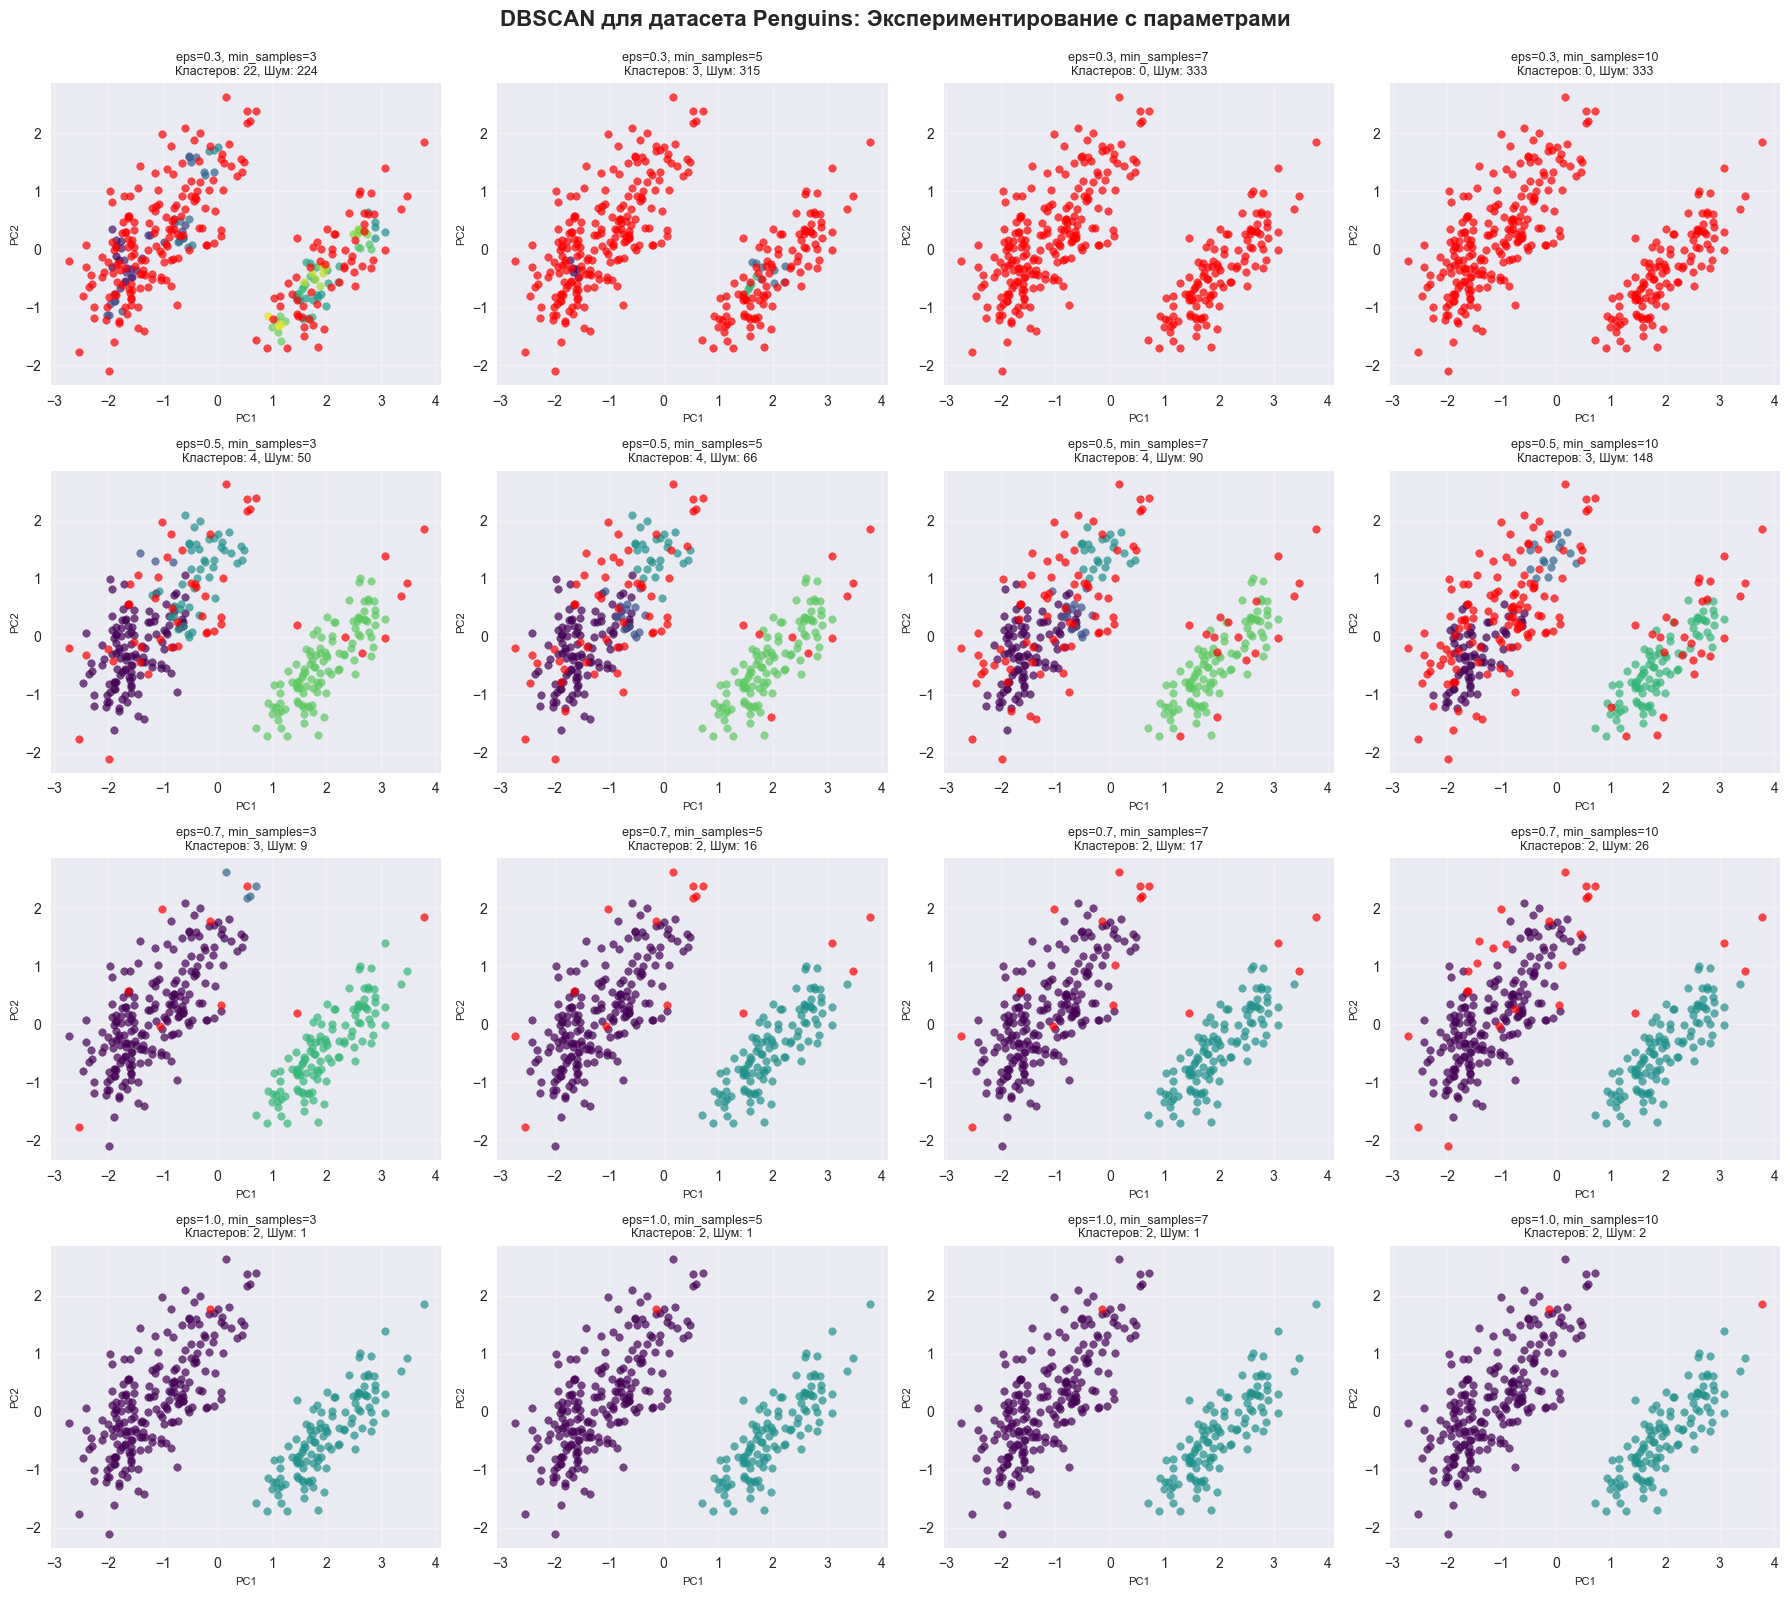

In [14]:
# Визуализация различных параметров DBSCAN
fig, axes = plt.subplots(len(eps_values_penguins), len(min_samples_values_penguins), 
                         figsize=(18, 16))
fig.suptitle('DBSCAN для датасета Penguins: Экспериментирование с параметрами', 
             fontsize=16, fontweight='bold', y=0.995)

for i, eps in enumerate(eps_values_penguins):
    for j, min_samples in enumerate(min_samples_values_penguins):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_penguins_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        ax = axes[i, j]
        unique_labels = set(labels)
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
        
        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = 'red'
            class_member_mask = (labels == k)
            xy = X_penguins_pca[class_member_mask]
            ax.scatter(xy[:, 0], xy[:, 1], c=[col], s=30, alpha=0.7)
        
        ax.set_title(f'eps={eps}, min_samples={min_samples}\n'
                    f'Кластеров: {n_clusters}, Шум: {n_noise}', 
                    fontsize=9)
        ax.set_xlabel('PC1', fontsize=8)
        ax.set_ylabel('PC2', fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('penguins_dbscan_parameters.png', dpi=150, bbox_inches='tight')
plt.show()


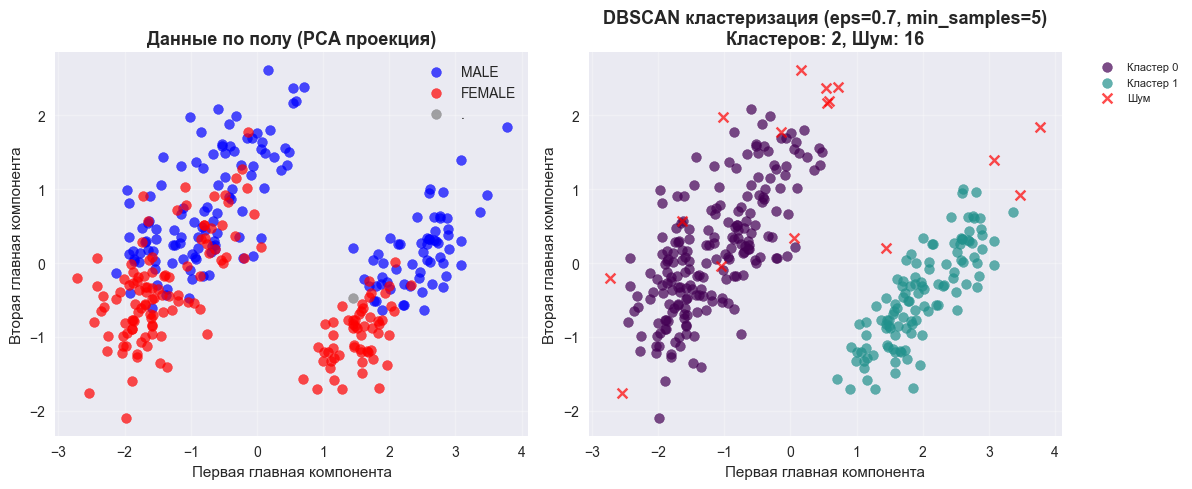

Количество кластеров DBSCAN: 2
Количество точек-шума: 16
Коэффициент силуэта для DBSCAN (без шума): 0.5500

Характеристики кластеров DBSCAN:

Кластер 0 (201 пингвинов):
culmen_length_mm       41.661692
culmen_depth_mm        18.319403
flipper_length_mm     191.741294
body_mass_g          3703.980100
dtype: float64

Кластер 1 (116 пингвинов):
culmen_length_mm       47.328448
culmen_depth_mm        14.939655
flipper_length_mm     216.905172
body_mass_g          5070.043103
dtype: float64


In [15]:
# Выбор оптимальных параметров DBSCAN для датасета Penguins
# Выбираем параметры с хорошим балансом между количеством кластеров и шумом
optimal_eps_penguins = 0.7
optimal_min_samples_penguins = 5

dbscan_penguins = DBSCAN(eps=optimal_eps_penguins, min_samples=optimal_min_samples_penguins)
y_dbscan_penguins = dbscan_penguins.fit_predict(X_penguins_scaled)

n_clusters_dbscan_penguins = len(set(y_dbscan_penguins)) - (1 if -1 in y_dbscan_penguins else 0)
n_noise_penguins = list(y_dbscan_penguins).count(-1)

# Визуализация результатов DBSCAN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
if 'sex' in df_penguins_clean.columns:
    sex_colors = {'MALE': 'blue', 'FEMALE': 'red'}
    for sex in df_penguins_clean['sex'].unique():
        if pd.notna(sex):
            mask = df_penguins_clean['sex'] == sex
            plt.scatter(X_penguins_pca[mask, 0], X_penguins_pca[mask, 1], 
                       c=sex_colors.get(sex, 'gray'), label=sex, s=50, alpha=0.7)
    plt.legend()
    plt.title('Данные по полу (PCA проекция)', fontsize=13, fontweight='bold')
else:
    plt.scatter(X_penguins_pca[:, 0], X_penguins_pca[:, 1], s=50, alpha=0.7)
    plt.title('Данные (PCA проекция)', fontsize=13, fontweight='bold')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
unique_labels = set(y_dbscan_penguins)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'red'
        marker = 'x'
        label = 'Шум'
    else:
        marker = 'o'
        label = f'Кластер {k}'
    class_member_mask = (y_dbscan_penguins == k)
    xy = X_penguins_pca[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=50, alpha=0.7, label=label)

plt.title(f'DBSCAN кластеризация (eps={optimal_eps_penguins}, min_samples={optimal_min_samples_penguins})\n'
          f'Кластеров: {n_clusters_dbscan_penguins}, Шум: {n_noise_penguins}', 
          fontsize=13, fontweight='bold')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('penguins_dbscan_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Количество кластеров DBSCAN: {n_clusters_dbscan_penguins}")
print(f"Количество точек-шума: {n_noise_penguins}")
if n_noise_penguins < len(X_penguins_scaled) * 0.1:
    silhouette_dbscan_penguins = silhouette_score(X_penguins_scaled[y_dbscan_penguins != -1], 
                                                   y_dbscan_penguins[y_dbscan_penguins != -1])
    print(f"Коэффициент силуэта для DBSCAN (без шума): {silhouette_dbscan_penguins:.4f}")

# Анализ кластеров DBSCAN
print("\nХарактеристики кластеров DBSCAN:")
for i in range(n_clusters_dbscan_penguins):
    cluster_mask = y_dbscan_penguins == i
    cluster_data = df_penguins_clean[cluster_mask]
    print(f"\nКластер {i} ({cluster_mask.sum()} пингвинов):")
    print(cluster_data[numeric_features].mean())


## Сравнение методов кластеризации

### Сравнение результатов на синтетических данных


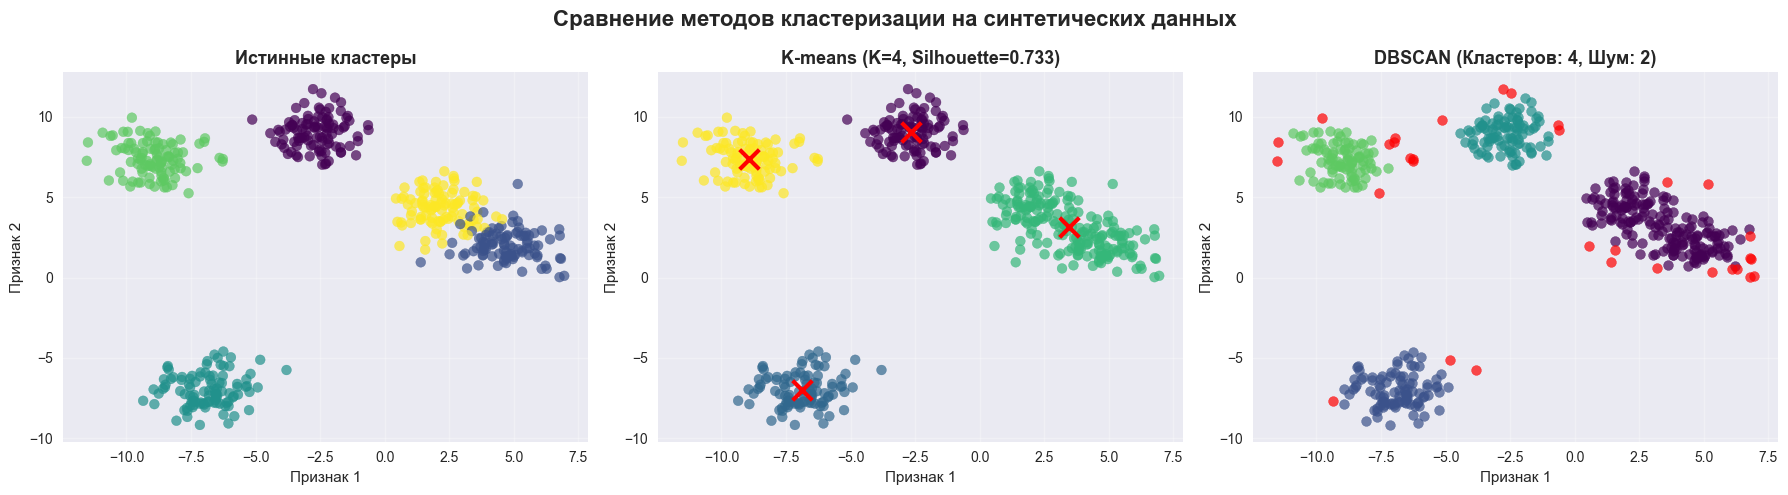

In [16]:
# Сравнительная визуализация для синтетических данных
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Сравнение методов кластеризации на синтетических данных', 
             fontsize=16, fontweight='bold')

# Истинные кластеры
axes[0].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_synthetic, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Истинные кластеры', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Признак 1')
axes[0].set_ylabel('Признак 2')
axes[0].grid(True, alpha=0.3)

# K-means
axes[1].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.7)
axes[1].scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1], 
                c='red', marker='x', s=200, linewidths=3)
axes[1].set_title(f'K-means (K={optimal_k_silhouette}, Silhouette={silhouette_avg:.3f})', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Признак 1')
axes[1].set_ylabel('Признак 2')
axes[1].grid(True, alpha=0.3)

# DBSCAN
unique_labels = set(y_dbscan)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'red'
    class_member_mask = (y_dbscan == k)
    xy = X_synthetic[class_member_mask]
    axes[2].scatter(xy[:, 0], xy[:, 1], c=[col], s=50, alpha=0.7)

axes[2].set_title(f'DBSCAN (Кластеров: {n_clusters_dbscan}, Шум: {n_noise})', 
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Признак 1')
axes[2].set_ylabel('Признак 2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('synthetic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Сравнение результатов на датасете Penguins


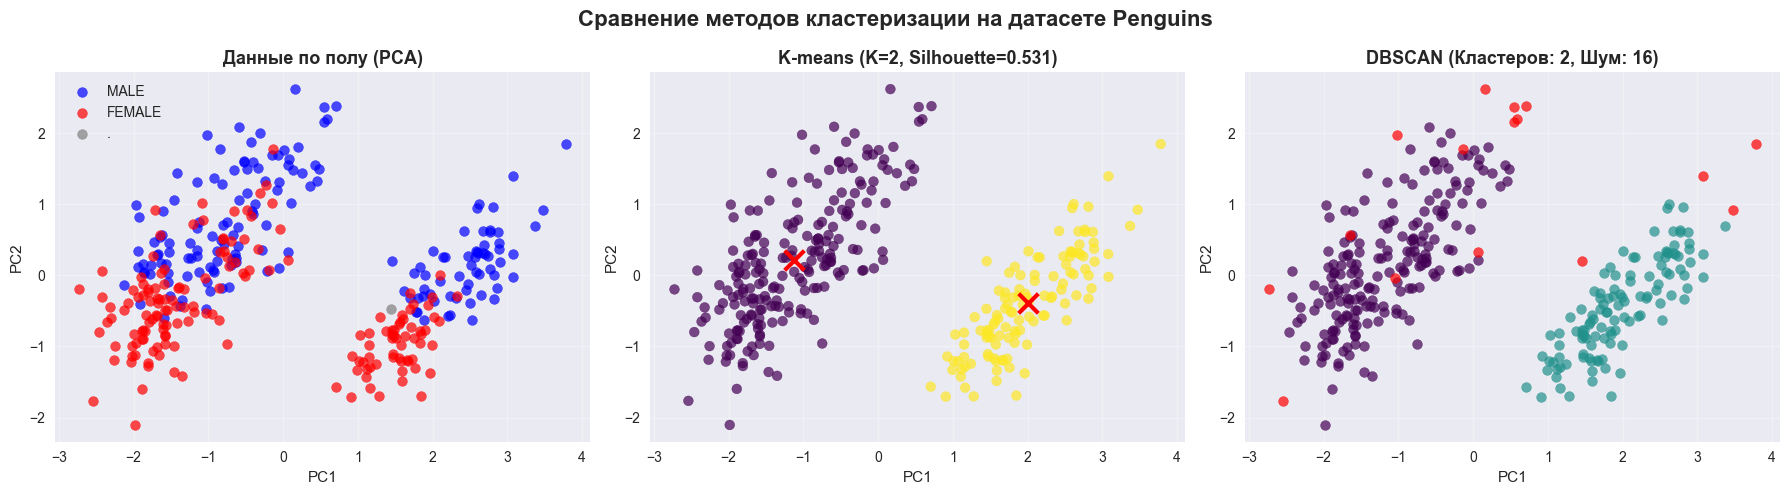

In [17]:
# Сравнительная визуализация для датасета Penguins
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Сравнение методов кластеризации на датасете Penguins', 
             fontsize=16, fontweight='bold')

# Исходные данные
if 'sex' in df_penguins_clean.columns:
    sex_colors = {'MALE': 'blue', 'FEMALE': 'red'}
    for sex in df_penguins_clean['sex'].unique():
        if pd.notna(sex):
            mask = df_penguins_clean['sex'] == sex
            axes[0].scatter(X_penguins_pca[mask, 0], X_penguins_pca[mask, 1], 
                          c=sex_colors.get(sex, 'gray'), label=sex, s=50, alpha=0.7)
    axes[0].legend()
    axes[0].set_title('Данные по полу (PCA)', fontsize=13, fontweight='bold')
else:
    axes[0].scatter(X_penguins_pca[:, 0], X_penguins_pca[:, 1], s=50, alpha=0.7)
    axes[0].set_title('Исходные данные (PCA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

# K-means
scatter = axes[1].scatter(X_penguins_pca[:, 0], X_penguins_pca[:, 1], 
                         c=y_kmeans_penguins, cmap='viridis', s=50, alpha=0.7)
axes[1].scatter(pca.transform(kmeans_penguins.cluster_centers_)[:, 0],
                pca.transform(kmeans_penguins.cluster_centers_)[:, 1],
                c='red', marker='x', s=200, linewidths=3)
axes[1].set_title(f'K-means (K={optimal_k_penguins}, Silhouette={silhouette_avg_penguins:.3f})', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True, alpha=0.3)

# DBSCAN
unique_labels = set(y_dbscan_penguins)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'red'
    class_member_mask = (y_dbscan_penguins == k)
    xy = X_penguins_pca[class_member_mask]
    axes[2].scatter(xy[:, 0], xy[:, 1], c=[col], s=50, alpha=0.7)

axes[2].set_title(f'DBSCAN (Кластеров: {n_clusters_dbscan_penguins}, Шум: {n_noise_penguins})', 
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('penguins_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
